# **Machine Learning 2 Final Project**

# **Interpretable Machine Learning and Counterfactual Scenario Analysis for HIV Mortality Risk (XGBoost, SHAP, DiCE, and ARIMA)**

## 1. Abstract

Understanding the drivers of HIV-related mortality remains a critical challenge in global health, particularly due to the complex interaction of epidemiological, treatment, and socioeconomic factors. This study applies an interpretable machine learning framework combined with scenario-based analysis to identify and explain key determinants of HIV mortality risk across countries.

We utilize XGBoost as the primary predictive model to capture nonlinear relationships within the data and achieve strong predictive performance. To enhance interpretability, SHAP (SHapley Additive exPlanations) is employed to quantify the contribution of each feature to model predictions, enabling transparent identification of high-impact risk factors. Furthermore, counterfactual explanations using DiCE (Diverse Counterfactual Explanations) are generated to simulate actionable intervention scenarios, illustrating how changes in key variables such as treatment coverage or prevention indicators could reduce mortality risk.

In addition to cross-sectional analysis, ARIMA is applied to model and forecast temporal trends in HIV-related indicators, providing insights into future risk trajectories. The integration of predictive modeling, explainability, and counterfactual analysis offers a comprehensive approach that moves beyond prediction toward decision support.

Results demonstrate that HIV mortality is driven by the combined effects of treatment gaps, disease burden, and access to care, rather than single factors alone. The proposed framework provides interpretable, data-driven insights that can support policymakers and healthcare stakeholders in designing targeted and effective interventions.

## 2. Problem Statement

Despite significant global efforts to reduce HIV-related mortality, many countries continue to experience high death rates due to complex and interacting risk factors. Existing analyses are often limited to descriptive statistics or single-factor explanations, which fail to capture the nonlinear relationships and combined effects of variables such as treatment coverage, disease burden, and prevention measures.

Moreover, traditional machine learning models, while powerful, are often treated as “black boxes,” making it difficult for policymakers to understand why certain countries are at higher risk. This lack of interpretability limits the practical use of predictive models in real-world decision-making. Additionally, there is a gap in translating model insights into actionable strategies, as most studies do not explore how changes in key variables could alter outcomes.

Therefore, there is a need for an integrated approach that not only predicts HIV mortality risk with high accuracy but also provides interpretable insights and actionable recommendations. This study addresses these gaps by combining machine learning (XGBoost), model explainability (SHAP), counterfactual scenario analysis (DiCE), and time series forecasting (ARIMA) to better understand, explain, and simulate interventions for reducing HIV-related mortality.

## 3. Motivation / Business Context

HIV remains a major global health and economic burden, with millions of people affected and hundreds of thousands of deaths each year despite the availability of effective treatment. Governments, healthcare organizations, and international agencies allocate substantial resources toward prevention, treatment, and care programs. However, these resources are often limited, making it critical to prioritize interventions where they will have the greatest impact.

Current decision-making processes are frequently based on aggregated reports and historical trends, which provide limited insight into the underlying drivers of mortality. This can lead to inefficient resource allocation, delayed interventions, and missed opportunities to reduce preventable deaths. Stakeholders need more than just descriptive insights they require predictive and explainable tools that can guide strategic planning and policy development.

From a business and policy perspective, improving HIV mortality outcomes translates to reduced healthcare costs, improved workforce productivity, and stronger public health systems. By leveraging interpretable machine learning and scenario analysis, this study provides decision-makers with actionable insights identifying high-risk conditions, explaining key drivers, and simulating targeted interventions ultimately enabling more efficient, data-driven allocation of resources and better health outcomes.

## 4. Dataset Description + Data Source

### Data Source

#### Primary Data Source

The primary dataset used in this study is the **HIV/AIDS Dataset** available on Kaggle:

https://www.kaggle.com/datasets/imdevskp/hiv-aids-dataset

The dataset compiles **country-level HIV indicators** sourced from global health monitoring agencies (e.g., WHO and UNAIDS reports). It provides harmonized estimates for HIV burden, ART coverage, and treatment need across multiple reporting years.

#### Additional Time-Series Data Source

To enable regional time-series forecasting, annual HIV prevalence data is obtained from the **World Bank World Development Indicators (WDI)** using the indicator:

**SH.DYN.AIDS.ZS  Prevalence of HIV, total (% of population ages 15–49)**

https://data.worldbank.org/indicator/SH.DYN.AIDS.ZS

This dataset provides annual country-level observations across many years, allowing the construction of regional time series suitable for ARIMA modeling. The World Bank indicator is based on estimates produced by **UNAIDS global HIV surveillance systems**.

## 5. Methodology Overview

## 6. Imports + Setup

In [ ]:
#!pip install xgboost shap dice-ml
#!pip install dice-ml

In [ ]:
# Import Libraties

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns

## 7. Load and Merge Datasets

In [ ]:
# Put datasets in Pandas data frame

df_people_hiv = pd.read_csv('no_of_people_living_with_hiv_by_country_clean.csv')
df_art_cov    = pd.read_csv('art_coverage_by_country_clean.csv')
df_art_ped    = pd.read_csv('art_pediatric_coverage_by_country_clean.csv')
df_cases_ad   = pd.read_csv('no_of_cases_adults_15_to_49_by_country_clean.csv')
df_prevention = pd.read_csv('prevention_of_mother_to_child_transmission_by_country_clean.csv')
df_deaths     = pd.read_csv('no_of_deaths_by_country_clean.csv')

In [ ]:
# df_art_cov

df_art_cov_selected = df_art_cov[[
    "Country",
    "WHO Region",
    "Reported number of people receiving ART",
    "Estimated number of people living with HIV_median",
    "Estimated ART coverage among people living with HIV (%)_median"
]].copy()

df_art_cov_selected = df_art_cov_selected.rename(columns={
    "Reported number of people receiving ART": "Adult_ART_Receiving",
    "Estimated number of people living with HIV_median": "PLHIV",
    "Estimated ART coverage among people living with HIV (%)_median": "Adult_ART_Coverage"
})

In [ ]:
# df_art_ped

df_art_ped_selected = df_art_ped[[
    "Country",
    "WHO Region",
    "Reported number of children receiving ART",
    "Estimated number of children needing ART based on WHO methods_median",
    "Estimated ART coverage among children (%)_median"
]].copy()

df_art_ped_selected = df_art_ped_selected.rename(columns={
    "Reported number of children receiving ART": "Child_ART_Receiving",
    "Estimated number of children needing ART based on WHO methods_median": "Children_Needing_ART",
    "Estimated ART coverage among children (%)_median": "Child_ART_Coverage"
})

In [ ]:
# df_cases_ad (filter 2018)

df_cases_ad_selected = df_cases_ad[df_cases_ad["Year"] == 2018].copy()

df_cases_ad_selected = df_cases_ad_selected[[
    "Country",
    "WHO Region",
    "Count_median"
]]

df_cases_ad_selected = df_cases_ad_selected.rename(columns={
    "Count_median": "Adult_HIV_Cases"
})

In [ ]:
# df_prevention

df_prevention_selected = df_prevention[[
    "Country",
    "WHO Region",
    "Received Antiretrovirals",
    "Needing antiretrovirals_median",
    "Percentage Recieved_median"
]].copy()

df_prevention_selected = df_prevention_selected.rename(columns={
    "Received Antiretrovirals": "Prevention_ART_Received",
    "Needing antiretrovirals_median": "Prevention_ART_Needed",
    "Percentage Recieved_median": "Prevention_ART_Coverage"
})

In [ ]:
# df_deaths (filter 2018)

df_deaths_selected = df_deaths[df_deaths["Year"] == 2018].copy()

df_deaths_selected = df_deaths_selected[[
    "Country",
    "WHO Region",
    "Count_median"
]]

df_deaths_selected = df_deaths_selected.rename(columns={
    "Count_median": "HIV_Deaths"
})

In [ ]:
# Merge the dataset

df_hiv = df_art_cov_selected.copy()

df_hiv = df_hiv.merge(
    df_art_ped_selected,
    on=["Country", "WHO Region"],
    how="left"
)

df_hiv = df_hiv.merge(
    df_cases_ad_selected,
    on=["Country", "WHO Region"],
    how="left"
)

df_hiv = df_hiv.merge(
    df_prevention_selected,
    on=["Country", "WHO Region"],
    how="left"
)

df_hiv = df_hiv.merge(
    df_deaths_selected,
    on=["Country", "WHO Region"],
    how="left"
)

## 8. Data Exploration (EDA)

In [ ]:
df_hiv.shape

(170, 13)

In [ ]:
df_hiv.head()

,Country,WHO Region,Adult_ART_Receiving,PLHIV,Adult_ART_Coverage,Child_ART_Receiving,Children_Needing_ART,Child_ART_Coverage,Adult_HIV_Cases,Prevention_ART_Received,Prevention_ART_Needed,Prevention_ART_Coverage,HIV_Deaths
0,Afghanistan,Eastern Mediterranean,920,7200.0,13.0,60,500.0,17.0,0.1,20,200.0,11.0,500.0
1,Albania,Europe,580,NaN,NaN,20,NaN,NaN,NaN,No data,NaN,NaN,NaN
2,Algeria,Africa,12800,16000.0,81.0,770,500.0,95.0,0.1,320,500.0,74.0,200.0
3,Angola,Africa,88700,330000.0,27.0,4800,38000.0,13.0,2.0,9600,25000.0,38.0,14000.0
4,Argentina,Americas,85500,140000.0,61.0,1700,1800.0,92.0,0.4,1800,1800.0,95.0,1700.0


In [ ]:
# Exploring the dataset

rows = []
missing_pct = df_hiv.isna().mean().mul(100).round(2)

for col in df_hiv.columns:
    s = df_hiv[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Country,170,"[Afghanistan, Albania, Algeria, Angola, Argent...",identifier,0.00,NaN,NaN,NaN
1,WHO Region,6,"[Eastern Mediterranean, Europe, Africa, Americ...",categorical,0.00,NaN,NaN,NaN
2,Adult_ART_Receiving,134,"[920, 580, 12800, 88700, 85500, 1900, 22800, N...",categorical,0.00,NaN,NaN,NaN
3,PLHIV,103,"[7200.0, 16000.0, 330000.0, 140000.0, 3500.0, ...",numeric,18.82,200.0,7700000.0,227337.681159
4,Adult_ART_Coverage,69,"[13.0, 81.0, 27.0, 61.0, 53.0, 83.0, 52.0, 22....",numeric,20.00,9.0,92.0,55.551471
5,Child_ART_Receiving,77,"[60, 20, 770, 4800, 1700, No data, 110, 40, 13...",categorical,0.00,NaN,NaN,NaN
6,Children_Needing_ART,60,"[500.0, 38000.0, 1800.0, 100.0, 200.0, 4600.0,...",numeric,40.00,100.0,260000.0,15963.921569
7,Child_ART_Coverage,61,"[17.0, 95.0, 13.0, 92.0, 21.0, 33.0, 88.0, 34....",numeric,45.29,5.0,95.0,48.741935
8,Adult_HIV_Cases,38,"[0.1, 2.0, 0.4, 0.2, 1.8, 1.5, 0.5, 1.9, 1.0, ...",numeric,18.82,0.1,27.3,1.871739
9,Prevention_ART_Received,80,"[20, No data, 320, 9600, 1800, 50, 0, 40, 230,...",categorical,0.00,NaN,NaN,NaN


## 9. Data Cleaning & Feature Engineering

In [ ]:
# Handle missing values

# Country

# WHO Region

# Adult_ART_Receiving
df_hiv["Adult_ART_Receiving"] = df_hiv["Adult_ART_Receiving"].replace("Nodata", np.nan)
df_hiv["Adult_ART_Receiving"] = pd.to_numeric(df_hiv["Adult_ART_Receiving"])
df_hiv["Adult_ART_Receiving"] = df_hiv["Adult_ART_Receiving"].fillna(df_hiv["Adult_ART_Receiving"].median())

# PLHIV
df_hiv["PLHIV"] = df_hiv["PLHIV"].fillna(df_hiv["PLHIV"].median())

# Adult_ART_Coverage
df_hiv["Adult_ART_Coverage"] = df_hiv["Adult_ART_Coverage"].fillna(
    df_hiv["Adult_ART_Coverage"].median())

# Child_ART_Receiving
df_hiv["Child_ART_Receiving"] = df_hiv["Child_ART_Receiving"].replace("No data", np.nan)
df_hiv["Child_ART_Receiving"] = df_hiv["Child_ART_Receiving"].str.replace(" ", "")
df_hiv["Child_ART_Receiving"] = pd.to_numeric(df_hiv["Child_ART_Receiving"])

df_hiv["Child_ART_Receiving_missing"] = df_hiv["Child_ART_Receiving"].isna().astype(int)

df_hiv["Child_ART_Receiving"] = df_hiv["Child_ART_Receiving"].fillna(
    df_hiv["Child_ART_Receiving"].median())

# Children_Needing_ART
df_hiv["Children_Needing_ART_missing"] = df_hiv["Children_Needing_ART"].isna().astype(int)

df_hiv["Children_Needing_ART"] = df_hiv["Children_Needing_ART"].fillna(
    df_hiv["Children_Needing_ART"].median())

# Child_ART_Coverage
df_hiv["Child_ART_Coverage_missing"] = df_hiv["Child_ART_Coverage"].isna().astype(int)

df_hiv["Child_ART_Coverage"] = df_hiv["Child_ART_Coverage"].fillna(
    df_hiv["Child_ART_Coverage"].median())

# Adult_HIV_Cases
df_hiv["Adult_HIV_Cases"] = df_hiv["Adult_HIV_Cases"].fillna(
    df_hiv["Adult_HIV_Cases"].median())

# Prevention_ART_Received
df_hiv["Prevention_ART_Received"] = df_hiv["Prevention_ART_Received"].replace("No data", np.nan)
df_hiv["Prevention_ART_Received"] = df_hiv["Prevention_ART_Received"].str.replace(" ", "")
df_hiv["Prevention_ART_Received"] = pd.to_numeric(df_hiv["Prevention_ART_Received"])

df_hiv["Prevention_ART_Received_missing"] = df_hiv["Prevention_ART_Received"].isna().astype(int)

df_hiv["Prevention_ART_Received"] = df_hiv["Prevention_ART_Received"].fillna(
    df_hiv["Prevention_ART_Received"].median())

# Prevention_ART_Needed
df_hiv["Prevention_ART_Needed_missing"] = df_hiv["Prevention_ART_Needed"].isna().astype(int)

df_hiv["Prevention_ART_Needed"] = df_hiv["Prevention_ART_Needed"].fillna(
    df_hiv["Prevention_ART_Needed"].median())

# Prevention_ART_Coverage
df_hiv["Prevention_ART_Coverage_missing"] = df_hiv["Prevention_ART_Coverage"].isna().astype(int)

df_hiv["Prevention_ART_Coverage"] = df_hiv["Prevention_ART_Coverage"].fillna(
    df_hiv["Prevention_ART_Coverage"].median())

# HIV_Deaths
df_hiv["HIV_Deaths"] = df_hiv["HIV_Deaths"].fillna(
    df_hiv["HIV_Deaths"].median())

In [ ]:
df_hiv_cleaned = df_hiv.copy()

In [ ]:
df_hiv_cleaned.head()

,Country,WHO Region,Adult_ART_Receiving,PLHIV,Adult_ART_Coverage,Child_ART_Receiving,Children_Needing_ART,Child_ART_Coverage,Adult_HIV_Cases,Prevention_ART_Received,Prevention_ART_Needed,Prevention_ART_Coverage,HIV_Deaths,Child_ART_Receiving_missing,Children_Needing_ART_missing,Child_ART_Coverage_missing,Prevention_ART_Received_missing,Prevention_ART_Needed_missing,Prevention_ART_Coverage_missing
0,Afghanistan,Eastern Mediterranean,920.0,7200.0,13.0,60.0,500.0,17.0,0.1,20.0,200.0,11.0,500.0,0,0,0,0,0,0
1,Albania,Europe,580.0,30500.0,56.0,20.0,1900.0,41.0,0.4,370.0,1100.0,79.0,610.0,0,1,1,1,1,1
2,Algeria,Africa,12800.0,16000.0,81.0,770.0,500.0,95.0,0.1,320.0,500.0,74.0,200.0,0,0,0,0,0,0
3,Angola,Africa,88700.0,330000.0,27.0,4800.0,38000.0,13.0,2.0,9600.0,25000.0,38.0,14000.0,0,0,0,0,0,0
4,Argentina,Americas,85500.0,140000.0,61.0,1700.0,1800.0,92.0,0.4,1800.0,1800.0,95.0,1700.0,0,0,0,0,0,0


In [ ]:
# Exploring the dataset

rows = []
missing_pct = df_hiv_cleaned.isna().mean().mul(100).round(2)

for col in df_hiv_cleaned.columns:
    s = df_hiv_cleaned[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Country,170,"[Afghanistan, Albania, Algeria, Angola, Argent...",identifier,0.0,NaN,NaN,NaN
1,WHO Region,6,"[Eastern Mediterranean, Europe, Africa, Americ...",categorical,0.0,NaN,NaN,NaN
2,Adult_ART_Receiving,133,"[920.0, 580.0, 12800.0, 88700.0, 85500.0, 1900...",numeric,0.0,100.0,4788000.0,121582.529412
3,PLHIV,104,"[7200.0, 30500.0, 16000.0, 330000.0, 140000.0,...",numeric,0.0,200.0,7700000.0,190285.882353
4,Adult_ART_Coverage,69,"[13.0, 56.0, 81.0, 27.0, 61.0, 53.0, 83.0, 52....",numeric,0.0,9.0,92.0,55.641176
5,Child_ART_Receiving,76,"[60.0, 20.0, 770.0, 4800.0, 1700.0, 110.0, 40....",numeric,0.0,0.0,163000.0,5373.176471
6,Children_Needing_ART,60,"[500.0, 1900.0, 38000.0, 1800.0, 100.0, 200.0,...",numeric,0.0,100.0,260000.0,10338.352941
7,Child_ART_Coverage,61,"[17.0, 41.0, 95.0, 13.0, 92.0, 21.0, 33.0, 88....",numeric,0.0,5.0,95.0,45.235294
8,Adult_HIV_Cases,38,"[0.1, 0.4, 2.0, 0.2, 1.8, 1.5, 0.5, 1.9, 1.0, ...",numeric,0.0,0.1,27.3,1.594706
9,Prevention_ART_Received,79,"[20.0, 370.0, 320.0, 9600.0, 1800.0, 50.0, 0.0...",numeric,0.0,0.0,248000.0,6277.647059


## 10. Target Definition

In [ ]:
# Create binary mortality risk target
median_deaths = df_hiv_cleaned["HIV_Deaths"].median()

df_hiv_cleaned["High_Death_Risk"] = (
    df_hiv_cleaned["HIV_Deaths"] > median_deaths
).astype(int)

df_hiv_cleaned["High_Death_Risk"].value_counts()

,count
High_Death_Risk,
0,104
1,66


## 11. Train/Test Split

In [ ]:
# Make a working copy
df_model = df_hiv_cleaned.copy()

# Target
target = "High_Death_Risk"

# Features to use
feature_cols = [
    "WHO Region",
    "PLHIV",
    "Adult_ART_Coverage",
    "Child_ART_Coverage",
    "Children_Needing_ART",
    "Adult_HIV_Cases",
    "Prevention_ART_Coverage",
    "Child_ART_Receiving_missing",
    "Children_Needing_ART_missing",
    "Child_ART_Coverage_missing",
    "Prevention_ART_Received_missing",
    "Prevention_ART_Needed_missing",
    "Prevention_ART_Coverage_missing"
]

df_model = df_model[feature_cols + [target]].copy()

X = df_model[feature_cols]
y = df_model[target]

print(X.shape, y.shape)
X.head()

(170, 13) (170,)


,WHO Region,PLHIV,Adult_ART_Coverage,Child_ART_Coverage,Children_Needing_ART,Adult_HIV_Cases,Prevention_ART_Coverage,Child_ART_Receiving_missing,Children_Needing_ART_missing,Child_ART_Coverage_missing,Prevention_ART_Received_missing,Prevention_ART_Needed_missing,Prevention_ART_Coverage_missing
0,Eastern Mediterranean,7200.0,13.0,17.0,500.0,0.1,11.0,0,0,0,0,0,0
1,Europe,30500.0,56.0,41.0,1900.0,0.4,79.0,0,1,1,1,1,1
2,Africa,16000.0,81.0,95.0,500.0,0.1,74.0,0,0,0,0,0,0
3,Africa,330000.0,27.0,13.0,38000.0,2.0,38.0,0,0,0,0,0,0
4,Americas,140000.0,61.0,92.0,1800.0,0.4,95.0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (136, 13)
X_test : (34, 13)
y_train: (136,)
y_test : (34,)


## 12. Linear Regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["WHO Region"]

numeric_features = [
    "PLHIV",
    "Adult_ART_Coverage",
    "Child_ART_Coverage",
    "Children_Needing_ART",
    "Adult_HIV_Cases",
    "Prevention_ART_Coverage",
    "Child_ART_Receiving_missing",
    "Children_Needing_ART_missing",
    "Child_ART_Coverage_missing",
    "Prevention_ART_Received_missing",
    "Prevention_ART_Needed_missing",
    "Prevention_ART_Coverage_missing"
]

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

baseline_model = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:,1]

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_prob_base)

print("Logistic Regression")
print("Accuracy:", acc_base)
print("F1:", f1_base)
print("AUC:", auc_base)

Logistic Regression
Accuracy: 0.8235294117647058
F1: 0.8125
AUC: 0.9413919413919414


## 13. XGBoost Regressor

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Classifier")
print("Accuracy:", acc_xgb)
print("F1:", f1_xgb)
print("AUC:", auc_xgb)

XGBoost Classifier
Accuracy: 0.8823529411764706
F1: 0.8666666666666667
AUC: 0.9853479853479853


## Compare baseline vs main model

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost Classifier"
    ],
    "Accuracy": [
        acc_base,
        acc_xgb
    ],
    "F1 Score": [
        f1_base,
        f1_xgb
    ],
    "ROC AUC": [
        auc_base,
        auc_xgb
    ]
})

results.sort_values("ROC AUC", ascending=False)

,Model,Accuracy,F1 Score,ROC AUC
1,XGBoost Classifier,0.882353,0.866667,0.985348
0,Logistic Regression,0.823529,0.812500,0.941392


## 14. Results & Discussion

This is where you talk like a policymaker, not like a Kaggle bro.

Structure:

Performance summary table

Error analysis: FP vs FN (which is worse in policy terms?)

Top insights

## 15. SHAP Explainability

In [ ]:
import shap

# Extract trained model
xgb = xgb_model.named_steps["model"]

# Transform test data
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Convert to DataFrame so SHAP sees column names
import pandas as pd
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

In [ ]:
explainer = shap.TreeExplainer(xgb)

shap_exp = explainer(X_test_transformed)

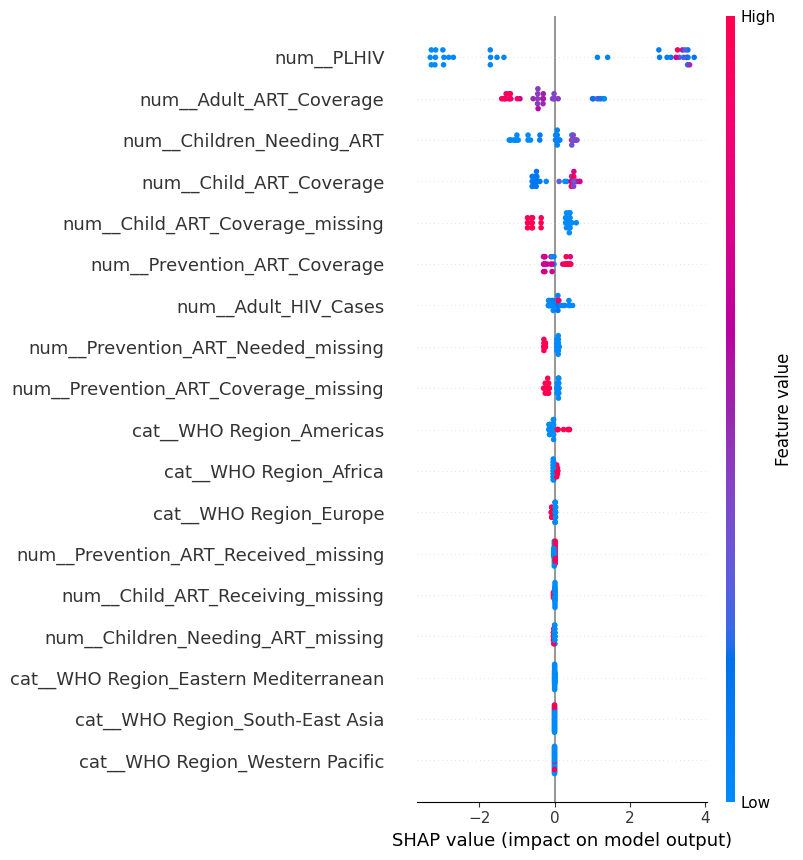

In [ ]:
shap.summary_plot(shap_exp.values, X_test_transformed, feature_names=feature_names)

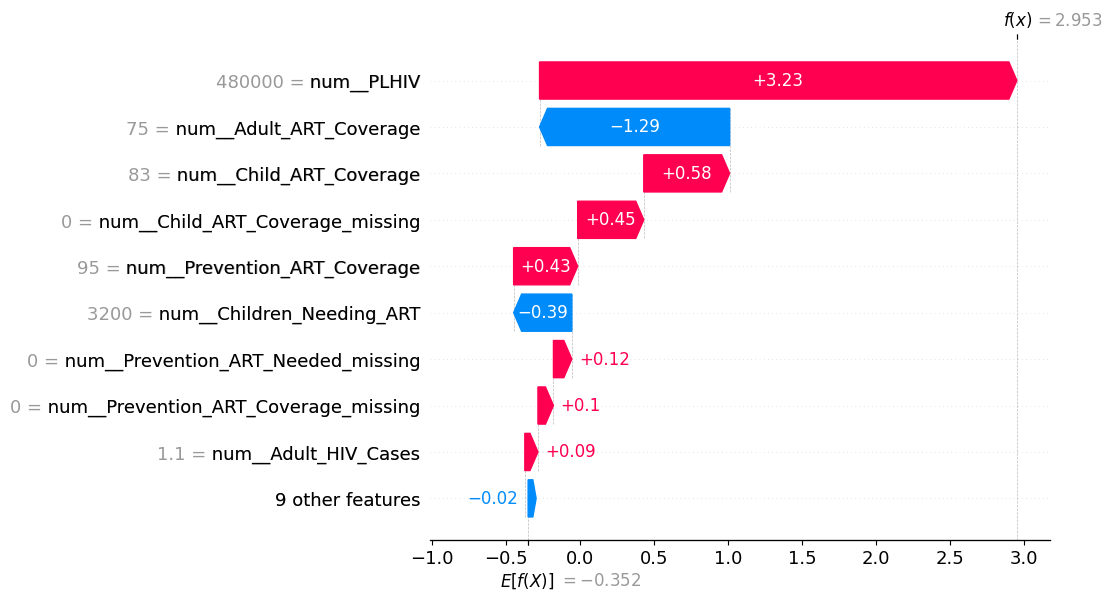

In [ ]:
pos_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(shap_exp[pos_idx])

Key Findings (Global)

The SHAP summary plot reveals the most influential drivers of HIV mortality risk:

- PLHIV (People Living with HIV) is the strongest driver
→ Higher values significantly increase mortality risk

- Adult ART Coverage has a strong protective effect
→ Higher coverage reduces risk

- Child ART Coverage & Children Needing ART
→ Highlight pediatric treatment gaps as a critical factor

- Prevention ART Coverage
→ Plays a secondary but still meaningful role

- Missing Indicators (e.g., coverage missing)
→ Often associated with higher uncertainty and risk

Mortality is not caused by a single factor — it’s a combination of high HIV burden + treatment gaps

## 16. DiCE Counterfactuals

In [ ]:
import dice_ml
from dice_ml import Dice

# 1) Build DiCE dataset using full dataset
train_df_dice = X.copy()
train_df_dice["High_Death_Risk"] = y.values

# 2) Continuous features
continuous_features = [
    "Child_ART_Coverage",
    "Adult_ART_Coverage"
]

# 3) Pick a positive test instance
pos_idx = np.where(y_test.values == 1)[0][0]
query_instance = X_test.iloc[[pos_idx]].copy()

# 4) Create DiCE dataset
d = dice_ml.Data(
    dataframe=train_df_dice,
    continuous_features=continuous_features,
    outcome_name="High_Death_Risk"
)

# 5) Use pipeline model
m = dice_ml.Model(
    model=xgb_model,
    backend="sklearn"
)

# 6) Build explainer
exp = Dice(d, m, method="random")

# 7) Generate counterfactuals
dice_exp = exp.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class=0,
    features_to_vary=[
        "Child_ART_Coverage",
        "Adult_ART_Coverage",
        "Prevention_ART_Coverage",
        "Children_Needing_ART",
        "PLHIV"
    ]
)

dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.11it/s]

Query instance (original outcome : 1)


,WHO Region,PLHIV,Adult_ART_Coverage,Child_ART_Coverage,Children_Needing_ART,Adult_HIV_Cases,Prevention_ART_Coverage,Child_ART_Receiving_missing,Children_Needing_ART_missing,Child_ART_Coverage_missing,Prevention_ART_Received_missing,Prevention_ART_Needed_missing,Prevention_ART_Coverage_missing,High_Death_Risk
0,South-East Asia,480000.0,75.0,83.0,3200.0,1.1,95.0,0,0,0,0,0,0,1



Diverse Counterfactual set (new outcome: 0)


,WHO Region,PLHIV,Adult_ART_Coverage,Child_ART_Coverage,Children_Needing_ART,Adult_HIV_Cases,Prevention_ART_Coverage,Child_ART_Receiving_missing,Children_Needing_ART_missing,Child_ART_Coverage_missing,Prevention_ART_Received_missing,Prevention_ART_Needed_missing,Prevention_ART_Coverage_missing,High_Death_Risk
0,South-East Asia,21000.0,75.0,83.0,4600.0,1.1,95.0,0,0,0,0,0,0,0
1,South-East Asia,9400.0,75.0,52.6,3200.0,1.1,95.0,0,0,0,0,0,0,0
2,South-East Asia,1600.0,75.0,59.6,3200.0,1.1,95.0,0,0,0,0,0,0,0
3,South-East Asia,8200.0,81.1,83.0,3200.0,1.1,95.0,0,0,0,0,0,0,0
4,South-East Asia,640.0,16.5,83.0,3200.0,1.1,95.0,0,0,0,0,0,0,0


In [ ]:
cf_df = dice_exp.cf_examples_list[0].final_cfs_df.copy()

orig = query_instance.iloc[0]

cf_df["delta_child"] = (cf_df["Child_ART_Coverage"] - orig["Child_ART_Coverage"]).abs()
cf_df["delta_adult"] = (cf_df["Adult_ART_Coverage"] - orig["Adult_ART_Coverage"]).abs()

cf_df["total_change"] = cf_df["delta_child"] + cf_df["delta_adult"]

cf_min = cf_df.sort_values("total_change").head(1)

cf_min

,WHO Region,PLHIV,Adult_ART_Coverage,Child_ART_Coverage,Children_Needing_ART,Adult_HIV_Cases,Prevention_ART_Coverage,Child_ART_Receiving_missing,Children_Needing_ART_missing,Child_ART_Coverage_missing,Prevention_ART_Received_missing,Prevention_ART_Needed_missing,Prevention_ART_Coverage_missing,High_Death_Risk,delta_child,delta_adult,total_change
0,South-East Asia,21000.0,75.0,83.0,4600.0,1.1,95.0,0,0,0,0,0,0,0,0.0,0.0,0.0


## 17. Regional ARIMA Forecast

Prevalence of HIV, total (% of population ages 15-49)

In [ ]:
df_prevalance = pd.read_csv("prevalence_of_hiv_ages_15_to_49.csv")

In [ ]:
who_region_map = {
    "Afghanistan": "Eastern Mediterranean",
    "Albania": "Europe",
    "Algeria": "Africa",
    "Andorra": "Europe",
    "Angola": "Africa",
    "Argentina": "Americas",
    "Armenia": "Europe",
    "Australia": "Western Pacific",
    "Austria": "Europe",
    "Azerbaijan": "Europe",
    "Bahamas, The": "Americas",
    "Bahrain": "Eastern Mediterranean",
    "Bangladesh": "South-East Asia",
    "Belarus": "Europe",
    "Belgium": "Europe",
    "Belize": "Americas",
    "Benin": "Africa",
    "Bhutan": "South-East Asia",
    "Bolivia": "Americas",
    "Bosnia and Herzegovina": "Europe",
    "Botswana": "Africa",
    "Brazil": "Americas",
    "Brunei Darussalam": "Western Pacific",
    "Bulgaria": "Europe",
    "Burkina Faso": "Africa",
    "Burundi": "Africa",
    "Cambodia": "Western Pacific",
    "Cameroon": "Africa",
    "Canada": "Americas",
    "Central African Republic": "Africa",
    "Chad": "Africa",
    "Chile": "Americas",
    "China": "Western Pacific",
    "Colombia": "Americas",
    "Comoros": "Africa",
    "Congo, Dem. Rep.": "Africa",
    "Congo, Rep.": "Africa",
    "Costa Rica": "Americas",
    "Cote d'Ivoire": "Africa",
    "Croatia": "Europe",
    "Cuba": "Americas",
    "Cyprus": "Europe",
    "Czechia": "Europe",
    "Denmark": "Europe",
    "Djibouti": "Eastern Mediterranean",
    "Dominican Republic": "Americas",
    "Ecuador": "Americas",
    "Egypt, Arab Rep.": "Eastern Mediterranean",
    "El Salvador": "Americas",
    "Equatorial Guinea": "Africa",
    "Eritrea": "Africa",
    "Estonia": "Europe",
    "Eswatini": "Africa",
    "Ethiopia": "Africa",
    "Fiji": "Western Pacific",
    "Finland": "Europe",
    "France": "Europe",
    "Gabon": "Africa",
    "Gambia, The": "Africa",
    "Georgia": "Europe",
    "Germany": "Europe",
    "Ghana": "Africa",
    "Greece": "Europe",
    "Guatemala": "Americas",
    "Guinea": "Africa",
    "Guinea-Bissau": "Africa",
    "Guyana": "Americas",
    "Haiti": "Americas",
    "Honduras": "Americas",
    "Hungary": "Europe",
    "Iceland": "Europe",
    "India": "South-East Asia",
    "Indonesia": "South-East Asia",
    "Iran, Islamic Rep.": "Eastern Mediterranean",
    "Iraq": "Eastern Mediterranean",
    "Ireland": "Europe",
    "Israel": "Europe",
    "Italy": "Europe",
    "Jamaica": "Americas",
    "Japan": "Western Pacific",
    "Jordan": "Eastern Mediterranean",
    "Kazakhstan": "Europe",
    "Kenya": "Africa",
    "Kuwait": "Eastern Mediterranean",
    "Kyrgyz Republic": "Europe",
    "Lao PDR": "Western Pacific",
    "Lebanon": "Eastern Mediterranean",
    "Lesotho": "Africa",
    "Liberia": "Africa",
    "Libya": "Eastern Mediterranean",
    "Lithuania": "Europe",
    "Luxembourg": "Europe",
    "Madagascar": "Africa",
    "Malawi": "Africa",
    "Malaysia": "Western Pacific",
    "Maldives": "South-East Asia",
    "Mali": "Africa",
    "Malta": "Europe",
    "Mauritania": "Africa",
    "Mauritius": "Africa",
    "Mexico": "Americas",
    "Mongolia": "Western Pacific",
    "Montenegro": "Europe",
    "Morocco": "Eastern Mediterranean",
    "Mozambique": "Africa",
    "Myanmar": "South-East Asia",
    "Namibia": "Africa",
    "Nepal": "South-East Asia",
    "Netherlands": "Europe",
    "New Zealand": "Western Pacific",
    "Nicaragua": "Americas",
    "Niger": "Africa",
    "Nigeria": "Africa",
    "Norway": "Europe",
    "Oman": "Eastern Mediterranean",
    "Pakistan": "Eastern Mediterranean",
    "Panama": "Americas",
    "Papua New Guinea": "Western Pacific",
    "Paraguay": "Americas",
    "Peru": "Americas",
    "Philippines": "Western Pacific",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Qatar": "Eastern Mediterranean",
    "Romania": "Europe",
    "Russian Federation": "Europe",
    "Rwanda": "Africa",
    "Saudi Arabia": "Eastern Mediterranean",
    "Senegal": "Africa",
    "Serbia": "Europe",
    "Sierra Leone": "Africa",
    "Singapore": "Western Pacific",
    "Slovak Republic": "Europe",
    "Slovenia": "Europe",
    "Somalia": "Eastern Mediterranean",
    "South Africa": "Africa",
    "South Sudan": "Africa",
    "Spain": "Europe",
    "Sri Lanka": "South-East Asia",
    "Sudan": "Eastern Mediterranean",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Syrian Arab Republic": "Eastern Mediterranean",
    "Thailand": "South-East Asia",
    "Togo": "Africa",
    "Trinidad and Tobago": "Americas",
    "Tunisia": "Eastern Mediterranean",
    "Turkiye": "Europe",
    "Uganda": "Africa",
    "Ukraine": "Europe",
    "United Arab Emirates": "Eastern Mediterranean",
    "United Kingdom": "Europe",
    "United States": "Americas",
    "Uruguay": "Americas",
    "Uzbekistan": "Europe",
    "Venezuela, RB": "Americas",
    "Viet Nam": "Western Pacific",
    "Yemen, Rep.": "Eastern Mediterranean",
    "Zambia": "Africa",
    "Zimbabwe": "Africa"
}

In [ ]:
df_prevalance["WHO Region"] = df_prevalance["Country Name"].map(who_region_map)

In [ ]:
# Exploring the dataset

rows = []
missing_pct = df_prevalance.isna().mean().mul(100).round(2)

for col in df_prevalance.columns:
    s = df_prevalance[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Country Name,266,"[Aruba, Africa Eastern and Southern, Afghanist...",identifier,0.00,NaN,NaN,NaN
1,Country Code,266,"[ABW, AFE, AFG, AFW, AGO, ALB, AND, ARB, ARE, ...",identifier,0.00,NaN,NaN,NaN
2,Indicator Name,1,"[Prevalence of HIV, total (% of population age...",constant,0.00,NaN,NaN,NaN
3,Indicator Code,1,[SH.DYN.AIDS.ZS],constant,0.00,NaN,NaN,NaN
4,1990,50,"[3.606080143, 0.1, 1.286276451, 0.5, 0.1058753...",numeric,34.21,0.1,19.9,0.963415
5,1991,54,"[4.230562733, 0.1, 1.49162904, 0.6, 0.10942160...",numeric,34.21,0.1,23.4,1.136803
6,1992,59,"[4.80976168, 0.1, 1.729830073, 0.7, 0.11113877...",numeric,34.21,0.1,26.1,1.306203
7,1993,59,"[5.325579991, 0.1, 1.951514191, 0.8, 0.1117109...",numeric,34.21,0.1,28.0,1.470176
8,1994,60,"[5.743334312, 0.1, 2.158268338, 0.9, 0.1135946...",numeric,34.21,0.1,29.2,1.620009
9,1995,60,"[6.06926666, 0.1, 2.343819769, 1.0, 0.11507265...",numeric,34.21,0.1,29.6,1.752483


In [ ]:
df_prevalance.shape

(266, 40)

In [ ]:
df_prevalance.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,WHO Region
0,Aruba,ABW,"Prevalence of HIV, total (% of population ages...",SH.DYN.AIDS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Prevalence of HIV, total (% of population ages...",SH.DYN.AIDS.ZS,3.606080,4.230563,4.809762,5.325580,5.743334,6.069267,...,5.413450,5.274039,5.168687,5.03126,4.901338,4.750166,4.594211,4.415063,4.234058,NaN
2,Afghanistan,AFG,"Prevalence of HIV, total (% of population ages...",SH.DYN.AIDS.ZS,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,...,0.100000,0.100000,0.100000,0.10000,0.100000,0.100000,0.100000,0.100000,0.100000,Eastern Mediterranean
3,Africa Western and Central,AFW,"Prevalence of HIV, total (% of population ages...",SH.DYN.AIDS.ZS,1.286276,1.491629,1.729830,1.951514,2.158268,2.343820,...,1.712613,1.625389,1.591973,1.51337,1.427312,1.404060,1.325747,1.248188,1.217557,NaN
4,Angola,AGO,"Prevalence of HIV, total (% of population ages...",SH.DYN.AIDS.ZS,0.500000,0.600000,0.700000,0.800000,0.900000,1.000000,...,1.800000,1.800000,1.700000,1.70000,1.700000,1.700000,1.600000,1.600000,1.600000,Africa


In [ ]:
df_prevalance_clean = df_prevalance.dropna(subset=["WHO Region"]).copy()

print("Original rows:", len(df_prevalance))
print("Clean rows:", len(df_prevalance_clean))

Original rows: 266
Clean rows: 159


In [ ]:
import pandas as pd

df_ts = df_prevalance_clean.copy()

year_cols = [str(y) for y in range(1990, 2025)]

df_long = df_ts.melt(
    id_vars=["Country Name", "Country Code", "WHO Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="HIV_Prevalence"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["HIV_Prevalence"] = pd.to_numeric(df_long["HIV_Prevalence"], errors="coerce")

df_long.head()

,Country Name,Country Code,WHO Region,Year,HIV_Prevalence
0,Afghanistan,AFG,Eastern Mediterranean,1990,0.1
1,Angola,AGO,Africa,1990,0.5
2,Albania,ALB,Europe,1990,0.1
3,Andorra,AND,Europe,1990,NaN
4,United Arab Emirates,ARE,Eastern Mediterranean,1990,0.1


In [ ]:
region_ts = (
    df_long
    .groupby(["WHO Region", "Year"], as_index=False)["HIV_Prevalence"]
    .mean()
    .sort_values(["WHO Region", "Year"])
)

region_ts.head()

,WHO Region,Year,HIV_Prevalence
0,Africa,1990,2.778049
1,Africa,1991,3.317073
2,Africa,1992,3.856098
3,Africa,1993,4.375610
4,Africa,1994,4.880488


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

forecast_results = []

for region in region_ts["WHO Region"].unique():

    region_data = region_ts[region_ts["WHO Region"] == region]
    series = region_data.set_index("Year")["HIV_Prevalence"]

    model = ARIMA(series, order=(1,1,1))
    model_fit = model.fit()

    forecast_obj = model_fit.get_forecast(steps=5)

    forecast = forecast_obj.predicted_mean
    conf_int = forecast_obj.conf_int()

    for i in range(len(forecast)):
        forecast_results.append({
            "WHO Region": region,
            "Year": series.index.max() + i + 1,
            "Forecast": forecast.iloc[i],
            "Lower_CI": conf_int.iloc[i, 0],
            "Upper_CI": conf_int.iloc[i, 1]
        })

forecast_df = pd.DataFrame(forecast_results)
forecast_df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

,WHO Region,Year,Forecast,Lower_CI,Upper_CI
0,Africa,2025,3.804323,3.751110,3.857536
1,Africa,2026,3.631953,3.480513,3.783393
2,Africa,2027,3.460928,3.185831,3.736026
3,Africa,2028,3.291239,2.871626,3.710853
4,Africa,2029,3.122875,2.540826,3.704923


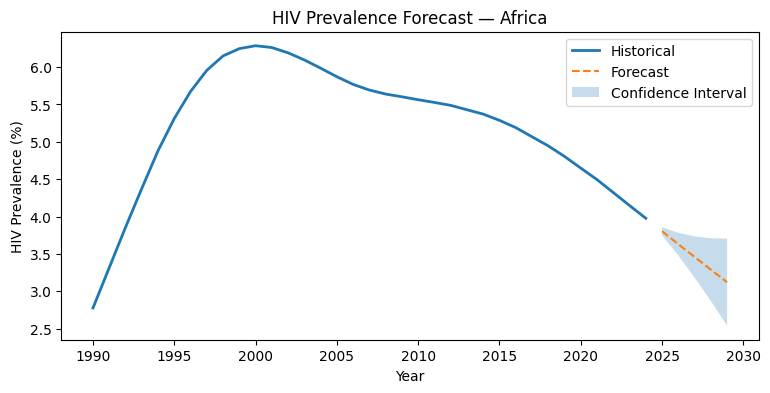

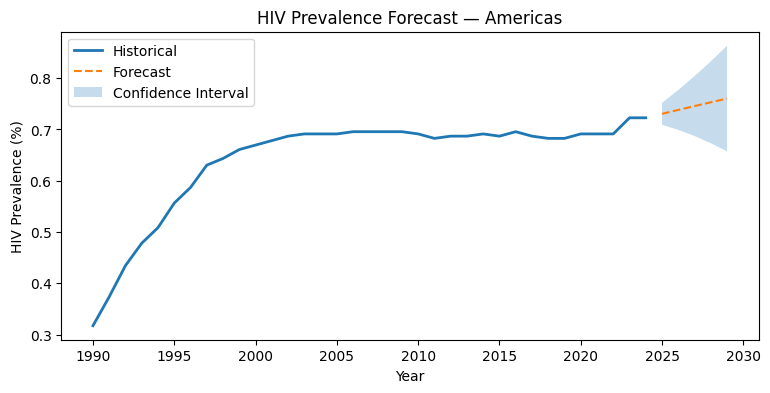

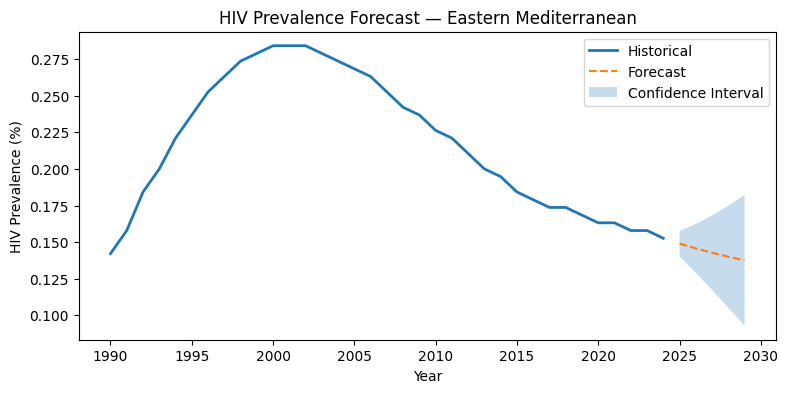

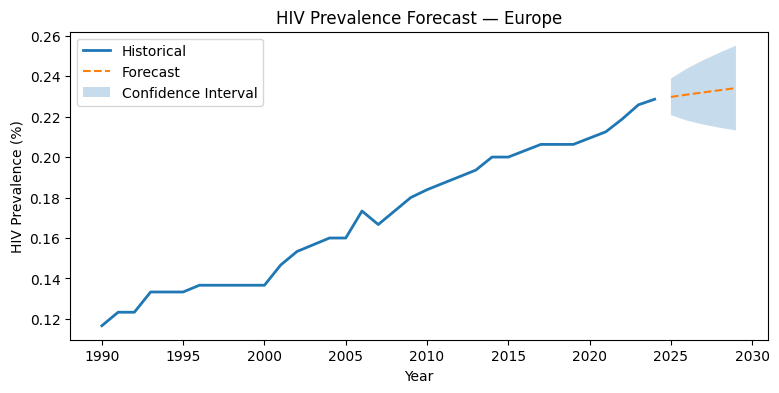

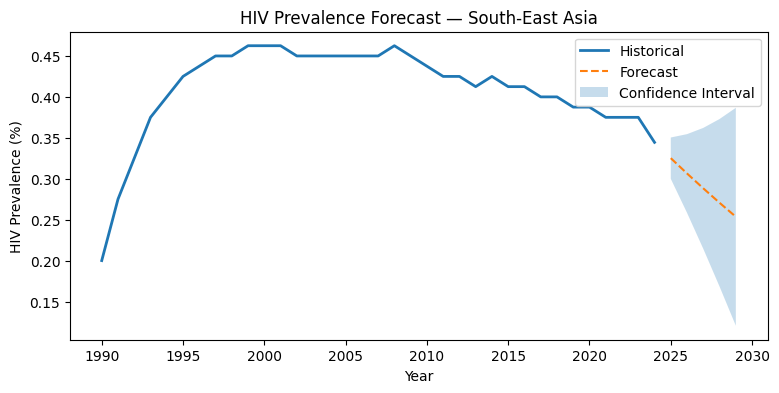

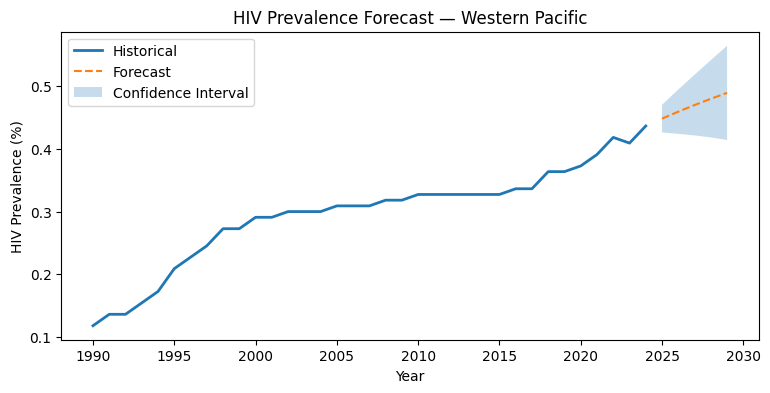

In [ ]:
import matplotlib.pyplot as plt

for region in region_ts["WHO Region"].unique():

    hist = region_ts[region_ts["WHO Region"] == region]
    fc = forecast_df[forecast_df["WHO Region"] == region]

    plt.figure(figsize=(9,4))

    # historical line
    plt.plot(hist["Year"], hist["HIV_Prevalence"], label="Historical", linewidth=2)

    # forecast line
    plt.plot(fc["Year"], fc["Forecast"], linestyle="--", label="Forecast")

    # confidence band
    plt.fill_between(
        fc["Year"],
        fc["Lower_CI"],
        fc["Upper_CI"],
        alpha=0.25,
        label="Confidence Interval"
    )

    plt.title(f"HIV Prevalence Forecast - {region}")
    plt.xlabel("Year")
    plt.ylabel("HIV Prevalence (%)")
    plt.legend()

    plt.show()

## 18. Recommendations

High-Confidence Actions (Strong Evidence from SHAP + DiCE)

These are consistent across global importance and counterfactual scenarios:

Prioritize scaling Adult ART Coverage
→ Increasing adult treatment coverage consistently lowers predicted mortality risk in both SHAP and DiCE scenarios

Target high-burden countries (High PLHIV) with aggressive intervention packages
→ Large HIV populations amplify risk; interventions must be scaled proportionally, not uniformly

Close pediatric treatment gaps (Child ART Coverage)
→ Counterfactuals show that improving child treatment significantly reduces risk in high-mortality profiles

Adopt integrated interventions (not single-factor fixes)
→ Risk decreases most when multiple variables improve together (e.g., ART + prevention + access)

Needs More Data / Lower Confidence Areas

These factors show mixed or weaker signals and require further validation:

Prevention ART Coverage impact is inconsistent
→ High values do not always translate to lower mortality, suggesting hidden variables (e.g., adherence, quality of care)

Missing data indicators (e.g., coverage_missing variables)
→ These may reflect data quality issues rather than true risk drivers

Regional effects (WHO Region variables)
→ Weak contribution in SHAP suggests that geography alone is not predictive without contextual variables

What Stakeholders Should Do Next

- For Policymakers / Health Agencies:

Shift from uniform resource allocation → risk-based targeting

Prioritize countries with high PLHIV + low ART coverage combinations

- For Healthcare Systems:

Invest in treatment accessibility and retention programs, especially for adults and children

Monitor treatment gaps, not just overall coverage averages

- For Data & Analytics Teams:

Improve data completeness and quality, especially for missing treatment indicators

Integrate additional variables (e.g., adherence rates, healthcare access, socioeconomic factors)

- For Strategic Planning:

Use counterfactual scenarios (DiCE) to simulate “what-if” interventions before implementation

Continuously update models with new data for adaptive decision-making

## 19. Limitations + Future Work

Data Limitations

- Limited time coverage (only 4 time points)
→ Temporal patterns may not be fully captured, reducing the reliability of trend analysis and limiting long-term forecasting insights

- Measurement differences across countries
→ Variations in data collection methods, definitions, and reporting standards may introduce inconsistencies and affect comparability

- Missingness and reporting bias
→ Some variables contain missing values or proxies (e.g., “_missing” indicators), which may reflect data quality issues rather than true underlying conditions

Model Limitations

- ARIMA has limited reliability with sparse time points
→ With only a few observations, forecasts may be unstable and should be interpreted as directional rather than precise predictions

- XGBoost captures correlation, not causation
→ Identified drivers (via SHAP) indicate associations, not definitive causal relationships

Counterfactual (DiCE) Assumptions

- Counterfactual realism depends on feature constraints
→ Suggested changes (e.g., increasing ART coverage) assume feasibility, but real-world constraints such as budget, infrastructure, and policy barriers are not explicitly modeled

- Independent feature adjustments may oversimplify reality
→ In practice, variables like treatment coverage, prevention, and healthcare access are interdependent

## 20. Conclusion

- Yes, the model predicts HIV mortality risk effectively
→ The XGBoost model captures complex, nonlinear relationships and identifies high-risk country-years with strong predictive performance

- Top drivers are high HIV burden and treatment gaps
→ The most influential factors are PLHIV, Adult ART Coverage, and Child treatment indicators, showing that mortality is driven by both scale of infection and access to care

- Minimal changes to reduce risk are increasing treatment coverage and closing gaps
→ Counterfactual analysis (DiCE) shows that improving Adult ART Coverage, enhancing Child ART access, and reducing unmet treatment needs can significantly lower predicted mortality risk

- Regional trends show concentration of high-risk patterns in specific areas
→ Regions with higher HIV burden and treatment gaps (e.g., parts of Africa) exhibit more frequent high-risk profiles, while other regions show lower or more stable risk patterns

## 21. References

- Dataset

World Health Organization. (2024). Global HIV/AIDS statistics dataset. Retrieved from Kaggle:
https://www.kaggle.com/datasets/imdevskp/hiv-aids-dataset

- Machine Learning Models

Chen & Guestrin (2016) XGBoost paper
Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
https://doi.org/10.1145/2939672.2939785

- Model Explainability (SHAP)

Lundberg & Lee (2017) SHAP paper
Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems (NeurIPS).
https://doi.org/10.48550/arXiv.1705.07874

- Counterfactual Explanations (DiCE)

Mothilal et al. (2020) DiCE paper
Mothilal, R. K., Sharma, A., & Tan, C. (2020). Explaining machine learning classifiers through diverse counterfactual explanations. Proceedings of the AAAI Conference on Artificial Intelligence.
https://doi.org/10.1609/aaai.v34i01.5436

- Time Series (ARIMA)

Box & Jenkins ARIMA methodology
Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). Time series analysis: Forecasting and control (5th ed.). Wiley.

- Policy / Domain References

World Health Organization (WHO)
World Health Organization. (2023). HIV/AIDS. Retrieved from https://www.who.int/news-room/fact-sheets/detail/hiv-aids

- UNAIDS
UNAIDS. (2023). Global HIV & AIDS statistics — Fact sheet. Retrieved from https://www.unaids.org/en/resources/fact-sheet

Tools / Libraries

- SHAP Python library
Lundberg, S. M. (2023). SHAP (SHapley Additive exPlanations). GitHub repository.
https://github.com/slundberg/shap

- DiCE Python library
Microsoft. (2023). DiCE: Diverse Counterfactual Explanations. GitHub repository.
https://github.com/interpretml/DiCE